# Handling Mixed Data

In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv('../../datasets/titanic3.csv')

In [3]:
data.head(2)

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1


In [4]:
data.isnull().sum()

Cabin       687
Ticket        0
number        0
Survived      0
dtype: int64

In [ ]:
// IMP

In [5]:
# how many categories are in number column
data['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

Text(0.5, 1.0, 'Number of members')

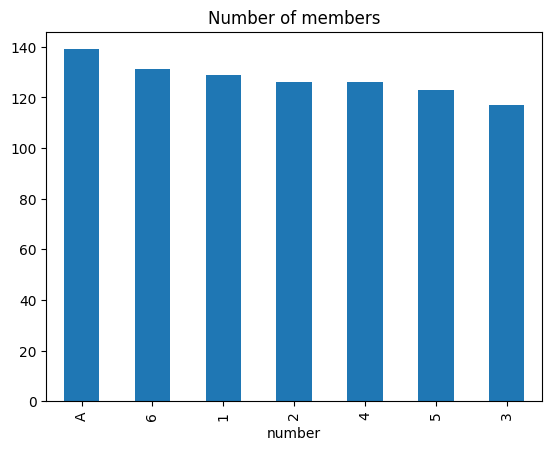

In [7]:
fig = data['number'].value_counts().plot.bar()
fig.set_title('Number of members')

In [8]:
# Moifying number column
data['number_numeric'] = pd.to_numeric(data['number'],errors='coerce',downcast='integer') # coerce -> It converts non numerical
# values into NAN


In [15]:
data.head(5)

,Cabin,Ticket,number,Survived,number_numeric,number_cat
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [12]:
data['number_cat'] = np.where(data['number_numeric'].isnull(),data['number'],np.nan)

In [20]:
data.head(5)

,Cabin,Ticket,number,Survived,number_numeric,number_cat
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


In [18]:
data['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [23]:
# Working cabin and Ticket feature
data['Cabin_numeric'] = data['Cabin'].str.extract('(\d+)') # capture Numeric part

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\dspri\AppData\Local\Temp\ipykernel_18972\345514885.py:2: SyntaxWarning: invalid escape sequence '\d'
  data['Cabin_numeric'] = data['Cabin'].str.extract('(\d+)') # capture Numeric part


In [24]:
data.head(1)

,Cabin,Ticket,number,Survived,number_numeric,number_cat,Cabin_numeric
0,NaN,A/5 21171,5,0,5.0,NaN,NaN


In [25]:
data['cabin_cat'] = data['Cabin'].str[0] # Extract the first letter 

In [26]:
data.head(1)

,Cabin,Ticket,number,Survived,number_numeric,number_cat,Cabin_numeric,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN


<Axes: xlabel='cabin_cat'>

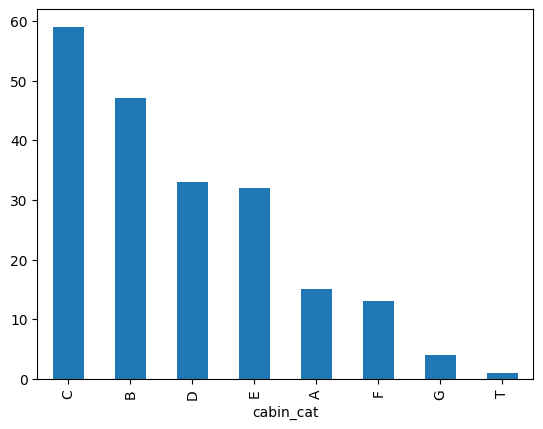

In [27]:
data['cabin_cat'].value_counts().plot(kind='bar')

In [28]:
# Extracting last of ticket as number
data['ticket_numeric'] = data['Ticket'].apply(lambda s : s.split()[-1])
data['ticket_numeric'] = pd.to_numeric(data['ticket_numeric'],errors='coerce',downcast='integer')

# Extracting the first bit of ticket
data['ticket_cat'] = data['Ticket'].apply(lambda s : s.split()[0])
data['ticket_cat'] = np.where(data['ticket_cat'].str.isdigit(),np.nan,data['ticket_cat'])


In [29]:
data.head(20)

,Cabin,Ticket,number,Survived,number_numeric,number_cat,Cabin_numeric,cabin_cat,ticket_numeric,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
5,NaN,330877,2,0,2.0,NaN,NaN,NaN,330877.0,NaN
6,E46,17463,2,0,2.0,NaN,46,E,17463.0,NaN
7,NaN,349909,5,0,5.0,NaN,NaN,NaN,349909.0,NaN
8,NaN,347742,1,1,1.0,NaN,NaN,NaN,347742.0,NaN
9,NaN,237736,A,1,NaN,A,NaN,NaN,237736.0,NaN


In [30]:
data['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [31]:
data['ticket_cat'].unique()

array(['A/5', 'PC', 'STON/O2.', nan, 'PP', 'A/5.', 'C.A.', 'A./5.',
       'SC/Paris', 'S.C./A.4.', 'A/4.', 'CA', 'S.P.', 'S.O.C.', 'SO/C',
       'W./C.', 'SOTON/OQ', 'W.E.P.', 'STON/O', 'A4.', 'C', 'SOTON/O.Q.',
       'SC/PARIS', 'S.O.P.', 'A.5.', 'Fa', 'CA.', 'LINE', 'F.C.C.', 'W/C',
       'SW/PP', 'SCO/W', 'P/PP', 'SC', 'SC/AH', 'A/S', 'A/4', 'WE/P',
       'S.W./PP', 'S.O./P.P.', 'F.C.', 'SOTON/O2', 'S.C./PARIS',
       'C.A./SOTON'], dtype=object)